In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [2]:
# load data
df = pd.read_csv("df_clean.csv")
df["date"] = pd.to_datetime(df["date"])
df.head()

,date,log_return,realized_variance,realized_volatility,gtrend_pct_change,blockchain_diff_log_n_transactions,blockchain_diff_log_transaction_fee_usd,blockchain_diff_log_n_unique_addresses,blockchain_diff_log_transaction_volume_usd,log_volume,...,brent_volume_chg,dji_volume_chg,spx_volume_chg,rut_volume_chg,nasdaq_volume_chg,vix_close_chg,hash-rate_chg,difficulty_chg,median-confirmation-time_chg,blockchain_log_mempool_count_chg
0,2016-06-15,0.019990,0.000528,0.022974,-0.138889,0.048912,0.154753,0.114522,-0.141196,8.976393,...,0.468585,0.004152,-0.058899,-0.058899,-0.063166,-0.017717,0.146603,0.0,0.089524,-0.003401
1,2016-06-16,0.096743,0.001641,0.040503,0.225806,0.032894,0.084044,0.034834,0.704898,9.729602,...,-0.224912,-0.023432,0.023300,0.023300,0.027134,-0.038982,-0.033006,0.0,-0.380307,-0.060516
2,2016-06-17,-0.022997,0.003730,0.061075,0.039474,-0.054144,-0.035212,-0.034919,-0.362618,9.547441,...,-0.184784,0.994922,0.311160,0.301013,0.353963,0.002063,0.000000,0.0,-0.037979,-0.003399
3,2016-06-18,0.008907,0.001710,0.041354,-0.177215,-0.075424,-0.124417,-0.069753,-0.418154,9.169094,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.064958,0.0,-0.182322,-0.033404
4,2016-06-19,0.012790,0.000586,0.024214,-0.076923,-0.075072,-0.097766,-0.024354,-0.288327,8.602203,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.107246,0.0,-0.255933,-0.132230


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3518 entries, 0 to 3517
Data columns (total 32 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   date                                        3518 non-null   datetime64[ns]
 1   log_return                                  3518 non-null   float64       
 2   realized_variance                           3518 non-null   float64       
 3   realized_volatility                         3518 non-null   float64       
 4   gtrend_pct_change                           3518 non-null   float64       
 5   blockchain_diff_log_n_transactions          3518 non-null   float64       
 6   blockchain_diff_log_transaction_fee_usd     3518 non-null   float64       
 7   blockchain_diff_log_n_unique_addresses      3518 non-null   float64       
 8   blockchain_diff_log_transaction_volume_usd  3518 non-null   float64       
 9   log_volu

# 2 regimes classification

In [4]:
# Determinstically regime classification according to paper using fixed window of 30 days

def rolling_percentile_rank(series, window=30):
    return series.rolling(window).apply(
        lambda x: (x <= x.iloc[-1]).mean(),
        raw=False
    )

def percentile_rank(df, window=30):
    df = df.copy()

    # rolling percentile ranks based only on past `window` observations
    df["p_sigma"] = rolling_percentile_rank(df["realized_volatility"], window=window)
    df["p_r"] = rolling_percentile_rank(df["log_return"], window=window)

    # distress score
    df["p_d"] = (df["p_sigma"] + (1 - df["p_r"])) / 2

    return df

def classify_regime_2(df):
    regimes = []
    prev_regime = None

    for _, row in df.iterrows():
        p_sigma = row["p_sigma"]

        if pd.isna(p_sigma):
            regime = np.nan

        # Low volatility
        elif p_sigma < 0.3:
            regime = "Low"

        # High volatility
        elif p_sigma > 0.6:
            regime = "High"

        # Buffer zone
        else:
            regime = prev_regime if prev_regime is not None else "Low"

        regimes.append(regime)

        if regime is not np.nan:
            prev_regime = regime

    return regimes

def classify_regime_3(df):
    regimes = []
    prev_regime = None

    for _, row in df.iterrows():
        p_sigma = row["p_sigma"]
        p_d = row["p_d"]

        if pd.isna(p_sigma) or pd.isna(p_d):
            regime = np.nan

        elif p_d > 0.85:
            regime = "Distress"

        elif p_sigma < 0.3:
            regime = "Low"

        elif 0.4 < p_sigma <= 0.6:
            regime = "High"

        # low/high buffer
        elif 0.3 <= p_sigma <= 0.4:
            regime = prev_regime if prev_regime is not None else "Low"

        # high/distress buffer
        elif 0.6 < p_sigma <= 0.7:
            regime = prev_regime if prev_regime is not None else "High"

        else:
            regime = prev_regime if prev_regime is not None else "High"

        regimes.append(regime)

        if regime is not np.nan:
            prev_regime = regime

    return regimes


In [5]:
# apply classification for 2 regimes

df2 = df.copy()
df2 = percentile_rank(df2)
df2["regime"] = classify_regime_2(df2)
df2["regime_id"] = df2["regime"].map({"Low": 0, "High": 1, "Distress": 2})

In [6]:
df2.head()

,date,log_return,realized_variance,realized_volatility,gtrend_pct_change,blockchain_diff_log_n_transactions,blockchain_diff_log_transaction_fee_usd,blockchain_diff_log_n_unique_addresses,blockchain_diff_log_transaction_volume_usd,log_volume,...,vix_close_chg,hash-rate_chg,difficulty_chg,median-confirmation-time_chg,blockchain_log_mempool_count_chg,p_sigma,p_r,p_d,regime,regime_id
0,2016-06-15,0.019990,0.000528,0.022974,-0.138889,0.048912,0.154753,0.114522,-0.141196,8.976393,...,-0.017717,0.146603,0.0,0.089524,-0.003401,NaN,NaN,NaN,NaN,NaN
1,2016-06-16,0.096743,0.001641,0.040503,0.225806,0.032894,0.084044,0.034834,0.704898,9.729602,...,-0.038982,-0.033006,0.0,-0.380307,-0.060516,NaN,NaN,NaN,NaN,NaN
2,2016-06-17,-0.022997,0.003730,0.061075,0.039474,-0.054144,-0.035212,-0.034919,-0.362618,9.547441,...,0.002063,0.000000,0.0,-0.037979,-0.003399,NaN,NaN,NaN,NaN,NaN
3,2016-06-18,0.008907,0.001710,0.041354,-0.177215,-0.075424,-0.124417,-0.069753,-0.418154,9.169094,...,0.000000,0.064958,0.0,-0.182322,-0.033404,NaN,NaN,NaN,NaN,NaN
4,2016-06-19,0.012790,0.000586,0.024214,-0.076923,-0.075072,-0.097766,-0.024354,-0.288327,8.602203,...,0.000000,0.107246,0.0,-0.255933,-0.132230,NaN,NaN,NaN,NaN,NaN


High    1920
Low     1569
Name: regime, dtype: int64


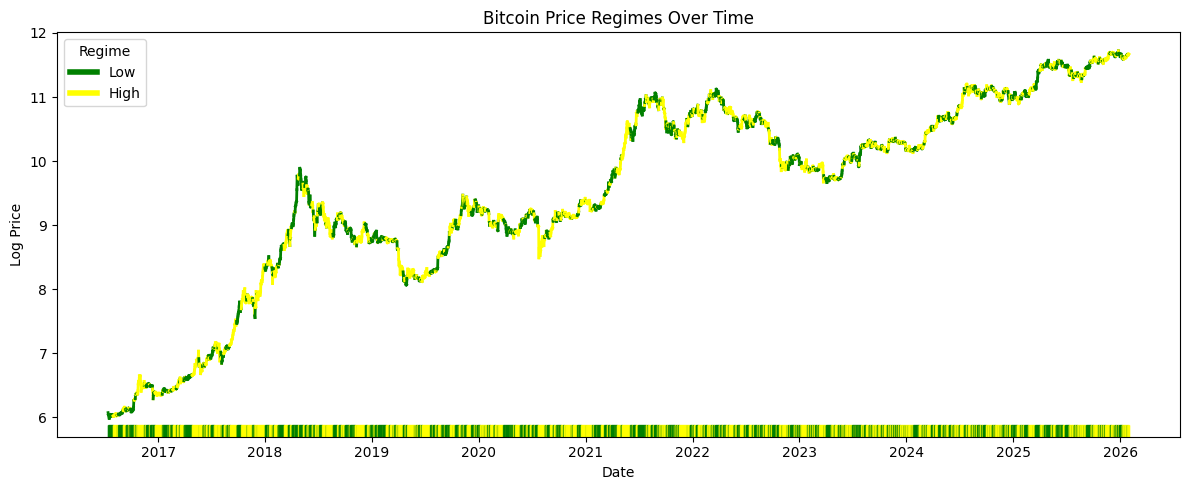

In [7]:
df3 = pd.read_csv("df.csv")

# class distribution
print(df2["regime"].value_counts())

regime_colors = {
    "Low": "green",
    "High": "yellow",
}

df2["date"] = pd.to_datetime(df2["date"])
df2 = df2.sort_values("date")

log_price = np.log(df3["close"])
fig, ax = plt.subplots(figsize=(12, 5))

for i in range(len(df2) - 1):

    regime = df2["regime"].iloc[i]

    
    if pd.isna(regime):
        continue

    
    if pd.isna(log_price.iloc[i]) or pd.isna(log_price.iloc[i+1]):
        continue

    x = df2["date"].iloc[i:i+2]
    y = log_price.iloc[i:i+2]

    ax.plot(x, y, color=regime_colors.get(regime, "gray"), linewidth=2)

ax.set_xlabel("Date")
ax.set_ylabel("Log Price")


for i in range(len(df2) - 1):

    regime = df2["regime"].iloc[i]

    if pd.isna(regime):
        continue

    x0 = df2["date"].iloc[i]
    x1 = df2["date"].iloc[i+1]

    ax.axvspan(
        x0, x1,
        ymin=0.0,
        ymax=0.03,
        color=regime_colors.get(regime, "gray"),
        alpha=0.8
    )

ax.set_title("Bitcoin Price Regimes Over Time")

handles = [plt.Line2D([0], [0], color=c, lw=4) for c in regime_colors.values()]
ax.legend(handles, regime_colors.keys(), title="Regime", loc="upper left")

plt.tight_layout()
plt.show()

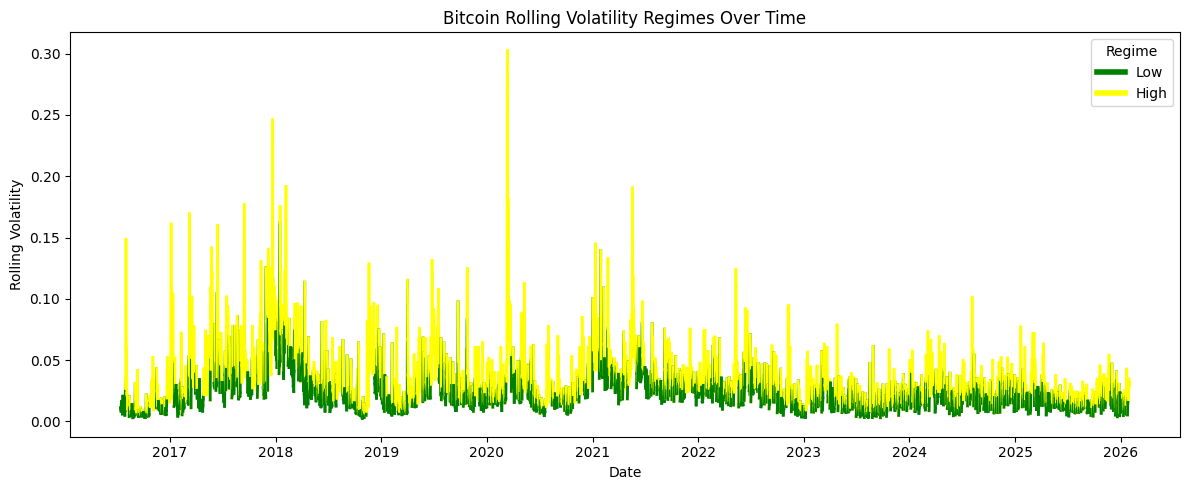

In [8]:
# plot of realised volatility regime classification
fig, ax = plt.subplots(figsize=(12, 5))
for i in range(len(df2)-1):

    regime = df2["regime"].iloc[i]

    if pd.isna(regime):
        continue

    x = df2["date"].iloc[i:i+2]
    y = df2["realized_volatility"].iloc[i:i+2]

    ax.plot(x, y, color=regime_colors[regime], lw=2)

ax.set_xlabel("Date")
ax.set_ylabel("Rolling Volatility")
ax.set_title("Bitcoin Rolling Volatility Regimes Over Time")

handles = [plt.Line2D([0],[0], color=c, lw=4) for c in regime_colors.values()]
ax.legend(handles, regime_colors.keys(), title="Regime")

plt.tight_layout()
plt.show()

In [9]:
# export to csv
df2.to_csv("df_with_2regimes.csv", index=False)

# 3 regime classification

In [10]:
# apply classification for 3 regimes

df4 = df.copy()
df4 = percentile_rank(df4)
df4["regime"] = classify_regime_3(df4)
df4["regime_id"] = df4["regime"].map({"Low": 0, "High": 1, "Distress": 2})

Low         1612
High        1151
Distress     726
Name: regime, dtype: int64


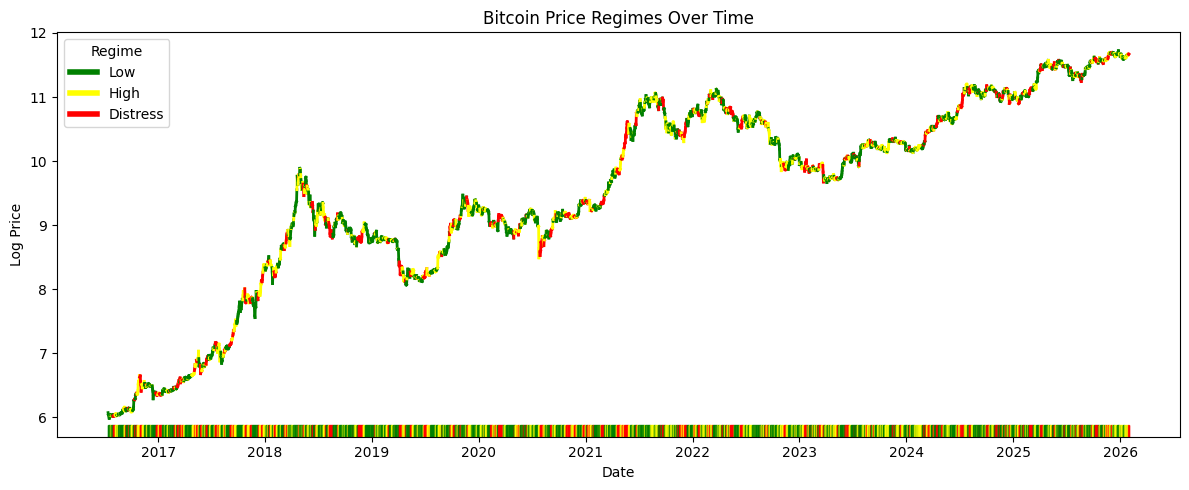

In [11]:
# class distribution
print(df4["regime"].value_counts())

regime_colors = {
    "Low": "green",
    "High": "yellow",
    "Distress": "red"   
}

df4["date"] = pd.to_datetime(df4["date"])
df4 = df4.sort_values("date")

log_price = np.log(df3["close"])
fig, ax = plt.subplots(figsize=(12, 5))

for i in range(len(df4) - 1):

    regime = df4["regime"].iloc[i]

    
    if pd.isna(regime):
        continue

    
    if pd.isna(log_price.iloc[i]) or pd.isna(log_price.iloc[i+1]):
        continue

    x = df4["date"].iloc[i:i+2]
    y = log_price.iloc[i:i+2]

    ax.plot(x, y, color=regime_colors.get(regime, "gray"), linewidth=2)

ax.set_xlabel("Date")
ax.set_ylabel("Log Price")


for i in range(len(df4) - 1):

    regime = df4["regime"].iloc[i]

    if pd.isna(regime):
        continue

    x0 = df4["date"].iloc[i]
    x1 = df4["date"].iloc[i+1]

    ax.axvspan(
        x0, x1,
        ymin=0.0,
        ymax=0.03,
        color=regime_colors.get(regime, "gray"),
        alpha=0.8
    )

ax.set_title("Bitcoin Price Regimes Over Time")

handles = [plt.Line2D([0], [0], color=c, lw=4) for c in regime_colors.values()]
ax.legend(handles, regime_colors.keys(), title="Regime", loc="upper left")

plt.tight_layout()
plt.show()

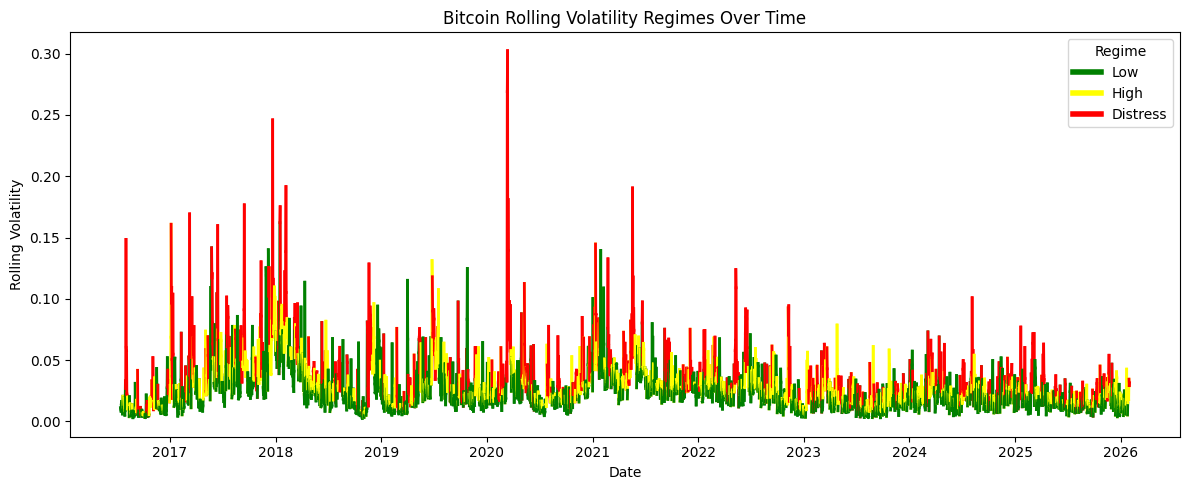

In [12]:
# plot of realised volatility regime classification
fig, ax = plt.subplots(figsize=(12, 5))
for i in range(len(df2)-1):

    regime = df4["regime"].iloc[i]

    if pd.isna(regime):
        continue

    x = df4["date"].iloc[i:i+2]
    y = df4["realized_volatility"].iloc[i:i+2]

    ax.plot(x, y, color=regime_colors[regime], lw=2)

ax.set_xlabel("Date")
ax.set_ylabel("Rolling Volatility")
ax.set_title("Bitcoin Rolling Volatility Regimes Over Time")

handles = [plt.Line2D([0],[0], color=c, lw=4) for c in regime_colors.values()]
ax.legend(handles, regime_colors.keys(), title="Regime")

plt.tight_layout()
plt.show()

In [13]:
# export to csv
df4.to_csv("df_with_3regimes.csv", index=False)